# Lake

## Deterministic

method          condition              n_obj    hv_ratio
PQL-Pareto      closed-loop                2     0.98242
PQL-Indicator   closed-loop                2     0.97865
PQL-Decomp      closed-loop                2     0.98955
NSGA-II         direct policy search       2     0.78113
NSGA-II         intertemporal              2     0.78705
IBEA            direct policy search       2     0.78409
IBEA            intertemporal              2     0.78742
MOEA/D          direct policy search       2     0.77616
MOEA/D          intertemporal              2     0.78640
PQL-Pareto      closed-loop                6     0.56665
PQL-Indicator   closed-loop                6     0.50726
PQL-Decomp      closed-loop                6     0.69852
NSGA-II         direct policy search       6     0.65827
NSGA-II         intertemporal              6     0.74575
IBEA            direct policy search       6     0.65827
IBEA            intertemporal              6     0.62849
MOEA/D          direct policy s

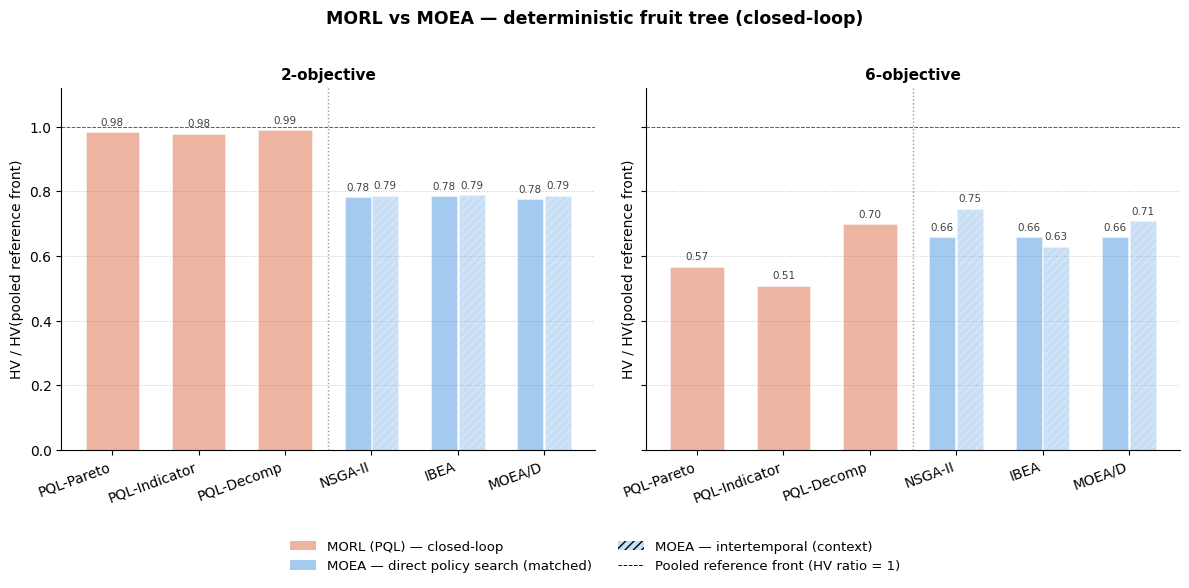

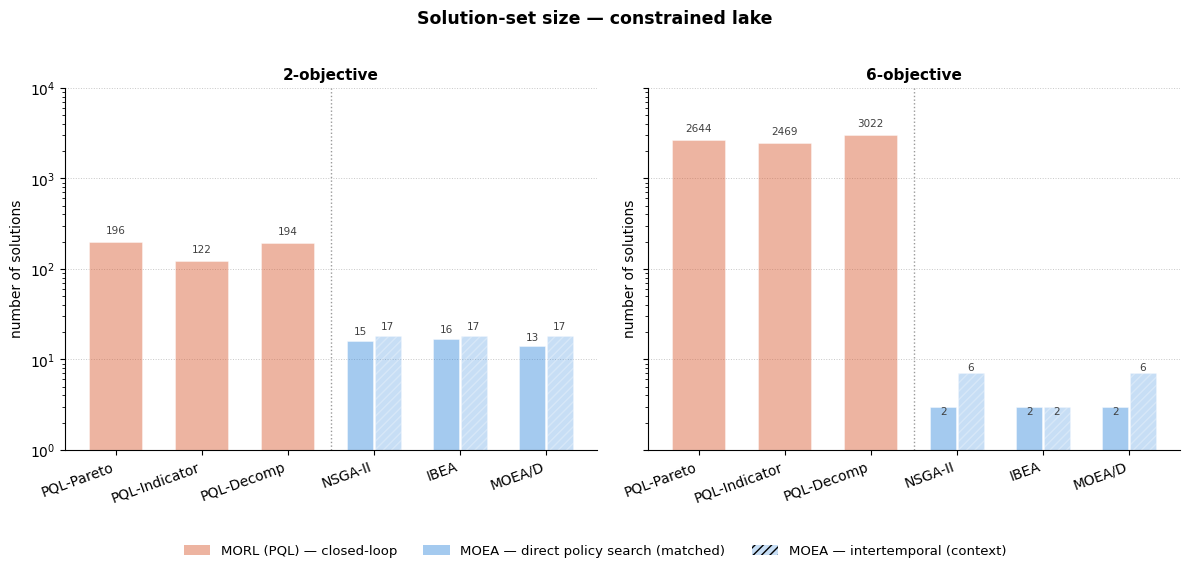

In [2]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pymoo.indicators.hv import HV

MORL_METHODS = ["pareto", "indicator", "decomposition"]
MOEA_METHODS = ["NSGAII", "IBEA", "MOEAD"]
ORDER = MORL_METHODS + MOEA_METHODS
METHOD_LABEL = {
    "pareto": "PQL-Pareto", "indicator": "PQL-Indicator", "decomposition": "PQL-Decomp",
    "NSGAII": "NSGA-II", "IBEA": "IBEA", "MOEAD": "MOEA/D",
}
PARADIGM_OF = {**{m: "MORL" for m in MORL_METHODS},
               **{m: "MOEA" for m in MOEA_METHODS}}
PARADIGM_COLOR = {"MORL": "#D85A30", "MOEA": "#378ADD"}
N_OBJS = [2, 6]

# Conditions per paradigm. MORL has the single inherent condition; MOEA has two.
MORL_CONDITIONS = ["closed_loop"]
MOEA_CONDITIONS = ["dps", "intertemporal"]
MATCHED_COND = "dps"          # the MOEA condition that is the fair match for PQL
# Per-condition bar styling (hue still comes from the paradigm).
COND_STYLE = {
    "closed_loop":   dict(alpha=0.45, hatch=""),
    "dps":           dict(alpha=0.45, hatch=""),
    "intertemporal": dict(alpha=0.28, hatch="////"),
}
COND_LABEL = {
    "closed_loop": "closed-loop",
    "dps": "direct policy search",
    "intertemporal": "intertemporal",
}


def _conditions_for(method):
    return MORL_CONDITIONS if PARADIGM_OF[method] == "MORL" else MOEA_CONDITIONS


def hypervolume(ref_point, points):
    """HV for MAX-convention objectives (matches morl_baselines' helper:
    negate everything and hand it to pymoo, which minimises)."""
    ref_point = np.asarray(ref_point, dtype=float)
    pts = np.asarray(points, dtype=float)
    if len(pts) == 0:
        return 0.0
    return float(HV(ref_point=ref_point * -1)(pts * -1))


def _obj_values(path, obj_is_negative):
    """Return the o1..oN columns of a results CSV as a MAX-convention array."""
    df = pd.read_csv(path)
    obj_cols = [c for c in df.columns if re.match(r'^o\d+$', c)]
    vals = np.abs(df[obj_cols].values) if obj_is_negative else df[obj_cols].values
    return vals


def _hv_of_csv(path, obj_is_negative, ref_value=-1.0):
    vals = _obj_values(path, obj_is_negative)
    if len(vals) == 0:
        return 0.0
    ref = np.full(vals.shape[1], ref_value)
    return hypervolume(ref, vals)


def _morl_dir(morl_base, scoring, n_obj):
    return os.path.join(morl_base, f'{scoring}_single_{n_obj}_seed0')


def _moea_dir(moea_base, cond, algo, n_obj):
    return os.path.join(moea_base, f'{cond}_{algo}_single_{n_obj}_seed0')


def _only_csv(folder, prefix):
    """The single results CSV in `folder` whose name starts with `prefix`."""
    if not os.path.isdir(folder):
        return None
    hits = [f for f in os.listdir(folder)
            if f.startswith(prefix) and f.endswith('.csv')]
    return os.path.join(folder, hits[0]) if hits else None


def _reference_hv(moea_base, morl_base, n_obj, ref_value=-1.0):
    """Pooled-front reference HV: HV of the union of every solution set for
    this n_obj.  Stand-in for the ground-truth front, which is not shipped
    with this dataset.  pymoo ignores dominated points, so feeding the raw
    union is equivalent to feeding its non-dominated subset."""
    pool = []
    for scoring in MORL_METHODS:
        csv = _only_csv(_morl_dir(morl_base, scoring, n_obj), 'pcs_')
        if csv:
            pool.append(_obj_values(csv, obj_is_negative=False))
    for algo in MOEA_METHODS:
        for cond in MOEA_CONDITIONS:
            csv = _only_csv(_moea_dir(moea_base, cond, algo, n_obj), 'archives_')
            if csv:
                pool.append(_obj_values(csv, obj_is_negative=True))
    pooled = np.vstack(pool)
    return hypervolume(np.full(n_obj, ref_value), pooled)


def load_values(moea_base, morl_base, ref_value=-1.0):
    """Return {(method, condition, n_obj): hv_ratio} — one scalar per cell."""
    out = {}
    for n_obj in N_OBJS:
        ref_hv = _reference_hv(moea_base, morl_base, n_obj, ref_value)

        # ── MORL: pcs_*.csv, positive (MAX-convention) objectives ──
        for scoring in MORL_METHODS:
            csv = _only_csv(_morl_dir(morl_base, scoring, n_obj), 'pcs_')
            if csv is None:
                continue
            hv = _hv_of_csv(csv, obj_is_negative=False, ref_value=ref_value)
            out[(scoring, "closed_loop", n_obj)] = hv / ref_hv

        # ── MOEA: archives_*.csv, negative objectives, two conditions ──
        for algo in MOEA_METHODS:
            for cond in MOEA_CONDITIONS:
                csv = _only_csv(_moea_dir(moea_base, cond, algo, n_obj),
                                'archives_')
                if csv is None:
                    continue
                hv = _hv_of_csv(csv, obj_is_negative=True, ref_value=ref_value)
                out[(algo, cond, n_obj)] = hv / ref_hv
    return out


def _n_solutions(path):
    """Number of solutions in a results CSV (one row == one solution)."""
    return len(pd.read_csv(path))


def load_counts(moea_base, morl_base):
    """Return {(method, condition, n_obj): n_solutions} — one count per cell."""
    out = {}
    for n_obj in N_OBJS:
        for scoring in MORL_METHODS:
            csv = _only_csv(_morl_dir(morl_base, scoring, n_obj), 'pcs_')
            if csv is None:
                continue
            out[(scoring, "closed_loop", n_obj)] = _n_solutions(csv)

        for algo in MOEA_METHODS:
            for cond in MOEA_CONDITIONS:
                csv = _only_csv(_moea_dir(moea_base, cond, algo, n_obj),
                                'archives_')
                if csv is None:
                    continue
                out[(algo, cond, n_obj)] = _n_solutions(csv)
    return out


def plot_panel(ax, data, n_obj, title):
    x = np.arange(len(ORDER))
    sub_w = 0.30          # width of a single sub-bar (MOEA, 2 conditions)
    solo_w = 0.62         # width of a solo bar (MORL, 1 condition)
    sub_off = 0.16        # +/- offset of MOEA sub-bars from the method centre

    for i, method in enumerate(ORDER):
        color = PARADIGM_COLOR[PARADIGM_OF[method]]
        conds = _conditions_for(method)
        for ci, cond in enumerate(conds):
            val = data.get((method, cond, n_obj), None)
            if val is None:
                continue
            if len(conds) == 1:
                bx, bw = i, solo_w
            else:
                bx = i + (ci - (len(conds) - 1) / 2.0) * (2 * sub_off)
                bw = sub_w
            style = COND_STYLE[cond]
            ax.bar(bx, val, width=bw, color=color,
                   alpha=style["alpha"], edgecolor='white', linewidth=0.6,
                   hatch=style["hatch"], zorder=2)
            ax.text(bx, val + 0.015, f'{val:.2f}', ha='center', va='bottom',
                    fontsize=7.5, color='0.25', zorder=4)

    ax.axvline(len(MORL_METHODS) - 0.5, color='0.6', linestyle=':',
               linewidth=1.0)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=0.7, alpha=0.6)

    # Full shared range. The reference line sits at 1.0; nothing can exceed it
    # because the pooled front contains every method's own points.
    ax.set_ylim(0, 1.12)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('HV / HV(pooled reference front)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABEL[m] for m in ORDER], rotation=20,
                       ha='right')
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


def plot_count_panel(ax, counts, n_obj, title):
    """Same bar layout as plot_panel, but the bar height is the number of
    solutions and the y-axis is log-scaled (the paradigms differ by orders
    of magnitude, so a linear axis would flatten every MOEA bar to nothing)."""
    x = np.arange(len(ORDER))
    sub_w = 0.30
    solo_w = 0.62
    sub_off = 0.16
    floor = 1            # log-axis baseline; bars are drawn up from here

    for i, method in enumerate(ORDER):
        color = PARADIGM_COLOR[PARADIGM_OF[method]]
        conds = _conditions_for(method)
        for ci, cond in enumerate(conds):
            val = counts.get((method, cond, n_obj), None)
            if val is None:
                continue
            if len(conds) == 1:
                bx, bw = i, solo_w
            else:
                bx = i + (ci - (len(conds) - 1) / 2.0) * (2 * sub_off)
                bw = sub_w
            style = COND_STYLE[cond]
            ax.bar(bx, val, width=bw, bottom=floor, color=color,
                   alpha=style["alpha"], edgecolor='white', linewidth=0.6,
                   hatch=style["hatch"], zorder=2)
            ax.text(bx, val * 1.18, f'{val:d}', ha='center', va='bottom',
                    fontsize=7.5, color='0.25', zorder=4)

    ax.axvline(len(MORL_METHODS) - 0.5, color='0.6', linestyle=':',
               linewidth=1.0)

    ax.set_yscale('log')
    ax.set_ylim(floor, 1e4)      # shared across panels; headroom for labels

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('number of solutions', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABEL[m] for m in ORDER], rotation=20,
                       ha='right')
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


if __name__ == '__main__':
    # Layout produced by unzipping deterministic.zip:
    #   deterministic/moea/<cond>_<algo>_single_<n>_seed0/archives_*.csv
    #   deterministic/morl/<scoring>_single_<n>_seed0/pcs_*.csv
    BASE = './constrained_lake_data/deterministic'
    MOEA_BASE = os.path.join(BASE, 'moea')
    MORL_BASE = os.path.join(BASE, 'morl')
    OUT = './tree_figures'
    os.makedirs(OUT, exist_ok=True)

    data = load_values(MOEA_BASE, MORL_BASE)

    # Numeric summary
    print(f"{'method':<16}{'condition':<22}{'n_obj':>6}{'hv_ratio':>12}")
    for n_obj in N_OBJS:
        for m in ORDER:
            for c in _conditions_for(m):
                v = data.get((m, c, n_obj), None)
                cell = '--' if v is None else f'{v:.5f}'
                print(f"{METHOD_LABEL[m]:<16}{COND_LABEL[c]:<22}"
                      f"{n_obj:>6}{cell:>12}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig.suptitle('MORL vs MOEA — deterministic fruit tree (closed-loop)',
                 fontsize=12.5, fontweight='bold', y=1.02)
    plot_panel(ax1, data, 2, '2-objective')
    plot_panel(ax2, data, 6, '6-objective')

    handles = [
        Patch(facecolor=PARADIGM_COLOR['MORL'],
              alpha=COND_STYLE['closed_loop']['alpha'],
              label='MORL (PQL) — closed-loop'),
        Patch(facecolor=PARADIGM_COLOR['MOEA'],
              alpha=COND_STYLE['dps']['alpha'],
              label='MOEA — direct policy search (matched)'),
        Patch(facecolor=PARADIGM_COLOR['MOEA'],
              alpha=COND_STYLE['intertemporal']['alpha'], hatch='////',
              label='MOEA — intertemporal (context)'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=0.7,
               label='Pooled reference front (HV ratio = 1)'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=2,
               bbox_to_anchor=(0.5, -0.13), frameon=False, fontsize=9.5)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, 'fig1_morl_vs_moea.png'),
                dpi=150, bbox_inches='tight')
    print(f"\nSaved {OUT}/fig1_morl_vs_moea.png")

    # ── Fig 2 — number of solutions per method ──────────────────────────────
    counts = load_counts(MOEA_BASE, MORL_BASE)

    print(f"\n{'method':<16}{'condition':<22}{'n_obj':>6}{'n_solutions':>13}")
    for n_obj in N_OBJS:
        for m in ORDER:
            for c in _conditions_for(m):
                v = counts.get((m, c, n_obj), None)
                cell = '--' if v is None else f'{v:d}'
                print(f"{METHOD_LABEL[m]:<16}{COND_LABEL[c]:<22}"
                      f"{n_obj:>6}{cell:>13}")

    fig2, (bx1, bx2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    fig2.suptitle('Solution-set size — constrained lake',
                  fontsize=12.5, fontweight='bold', y=1.02)
    plot_count_panel(bx1, counts, 2, '2-objective')
    plot_count_panel(bx2, counts, 6, '6-objective')

    handles2 = [
        Patch(facecolor=PARADIGM_COLOR['MORL'],
              alpha=COND_STYLE['closed_loop']['alpha'],
              label='MORL (PQL) — closed-loop'),
        Patch(facecolor=PARADIGM_COLOR['MOEA'],
              alpha=COND_STYLE['dps']['alpha'],
              label='MOEA — direct policy search (matched)'),
        Patch(facecolor=PARADIGM_COLOR['MOEA'],
              alpha=COND_STYLE['intertemporal']['alpha'], hatch='////',
              label='MOEA — intertemporal (context)'),
    ]
    fig2.legend(handles=handles2, loc='lower center', ncol=3,
                bbox_to_anchor=(0.5, -0.10), frameon=False, fontsize=9.5)
    fig2.tight_layout()
    fig2.savefig(os.path.join(OUT, 'fig2_solution_counts.png'),
                 dpi=150, bbox_inches='tight')
    print(f"Saved {OUT}/fig2_solution_counts.png")

## Robustness

In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from morl_baselines.common.performance_indicators import hypervolume

ALGO_LABELS = {"IBEA": "IBEA", "NSGAII": "NSGA-II", "MOEAD": "MOEA/D"}
ALGO_COLORS = {"IBEA": "#378ADD", "NSGAII": "#D85A30", "MOEAD": "#1D9E75"}

COND_LABEL = {
    "intertemporal_moro":  "Intertemporal — MORO",
    "intertemporal_multi": "Intertemporal — Multi",
    "dps_moro":            "DPS — MORO",
    "dps_multi":           "DPS — Multi",
}

COND_ALPHA = {
    "intertemporal_moro":  1.0,
    "intertemporal_multi": 1.0,
    "dps_moro":            0.55,
    "dps_multi":           0.55,
}
COND_HATCH = {
    "intertemporal_moro":  "",
    "intertemporal_multi": "//",
    "dps_moro":            "",
    "dps_multi":           "//",
}

ALGOS      = ["IBEA", "NSGAII", "MOEAD"]
CONDITIONS = ["intertemporal_moro", "intertemporal_multi",
              "dps_moro",           "dps_multi"]
N_OBJS     = [2, 6]


FOLDER_RE = re.compile(
    r'^(dps|intertemporal)_(NSGAII|IBEA|MOEAD)_(moro|multi)_(\d+)$'
)

OBJ_COL_RE = re.compile(r'^o\d+(_mean)?$')


def _evaluated_csv(folder_path):
    files = os.listdir(folder_path)
    evaluated = sorted(f for f in files
                       if f.startswith('archives_') and f.endswith('_evaluated.csv'))
    return evaluated[0] if evaluated else None


def _compute_hv(df, ref_value=-1.0):
    obj_cols = [c for c in df.columns if OBJ_COL_RE.match(c)]
    if not obj_cols:
        return None, 0
    vals = np.abs(df[obj_cols].values)
    if len(vals) == 0:
        return 0.0, 0
    ref = np.full(len(obj_cols), ref_value)
    return hypervolume(ref, [tuple(r) for r in vals]), len(vals)


def _parse_runtime_seconds(folder_path):
    files = os.listdir(folder_path)
    convs = sorted(f for f in files
                   if f.startswith('convergences_') and f.endswith('.csv'))
    if not convs:
        return None

    last_seconds = []
    for c in convs:
        df = pd.read_csv(os.path.join(folder_path, c))
        if 'time' not in df.columns or len(df) == 0:
            continue
        last = str(df['time'].iloc[-1])
        try:
            h, m, s = map(int, last.split(':'))
            last_seconds.append(h * 3600 + m * 60 + s)
        except (ValueError, AttributeError):
            continue

    return max(last_seconds) if last_seconds else None


def load_dataset(base, ref_value=-1.0):
    records = []
    for d in sorted(os.listdir(base)):
        m = FOLDER_RE.match(d)
        if not m:
            continue
        policy, algo, method, n_obj = m.groups()
        n_obj = int(n_obj)
        condition = f"{policy}_{method}"
        if condition not in CONDITIONS:
            continue

        folder_path = os.path.join(base, d)
        csv_name = _evaluated_csv(folder_path)
        if csv_name is None:
            print(f'WARNING: no *_evaluated.csv in {folder_path}, skipping')
            continue

        df = pd.read_csv(os.path.join(folder_path, csv_name))
        hv, n_points = _compute_hv(df, ref_value=ref_value)
        if hv is None:
            print(f'WARNING: no objective columns in {csv_name}, skipping')
            continue

        runtime_s = _parse_runtime_seconds(folder_path)
        records.append({
            'condition': condition, 'algo': algo, 'method': method,
            'policy': policy, 'n_obj': n_obj,
            'hv': hv, 'n_points': n_points,
            'runtime_s': runtime_s,
        })
    return pd.DataFrame(records)


def aggregate(df):
    grouped = df.groupby(['condition', 'algo', 'n_obj']).agg(
        hv_mean=('hv', 'mean'),
        hv_std=('hv', 'std'),
        n_seeds=('hv', 'count'),
        n_points_mean=('n_points', 'mean'),
        n_points_std=('n_points', 'std'),
        runtime_mean=('runtime_s', 'mean'),
        runtime_std=('runtime_s', 'std'),
    ).reset_index()
    grouped['hv_std'] = grouped['hv_std'].fillna(0.0)
    grouped['n_points_std'] = grouped['n_points_std'].fillna(0.0)
    grouped['runtime_std'] = grouped['runtime_std'].fillna(0.0)
    return grouped


def plot_bars(ax, agg, n_obj, title, metric='hv'):
    subset = agg[agg['n_obj'] == n_obj]
    x = np.arange(len(ALGOS))
    width = 0.20
    n_cond = len(CONDITIONS)
    offsets = (np.arange(n_cond) - (n_cond - 1) / 2.0) * width

    has_variance = (subset['n_seeds'] > 1).any()

    if metric == 'hv':
        mean_col, std_col, ylabel = 'hv_mean', 'hv_std', 'Hypervolume'
        label_fmt = lambda v: f'{v:#.4g}'
    elif metric == 'n_points':
        mean_col, std_col, ylabel = 'n_points_mean', 'n_points_std', 'Number of solutions'
        label_fmt = lambda v: f'{v:.0f}'
    elif metric == 'runtime':
        mean_col, std_col, ylabel = 'runtime_mean', 'runtime_std', 'Runtime (s)'
        label_fmt = lambda v: f'{v:.0f}'
    else:
        raise ValueError(
            f"metric must be 'hv', 'n_points', or 'runtime'; got {metric!r}"
        )

    for offset, cond in zip(offsets, CONDITIONS):
        means, stds = [], []
        for algo in ALGOS:
            row = subset[(subset['algo'] == algo) & (subset['condition'] == cond)]
            if len(row) == 0:
                means.append(0.0)
                stds.append(0.0)
            else:
                means.append(float(row[mean_col].iloc[0]))
                stds.append(float(row[std_col].iloc[0]))

        bars = ax.bar(
            x + offset, means, width=width,
            yerr=stds if has_variance else None,
            capsize=3 if has_variance else 0,
            label=COND_LABEL[cond],
            color=[ALGO_COLORS[a] for a in ALGOS],
            alpha=COND_ALPHA[cond],
            edgecolor='white', linewidth=0.5,
            hatch=COND_HATCH[cond],
            error_kw={'ecolor': '0.3', 'linewidth': 0.8} if has_variance else {},
        )
        ax.bar_label(
            bars,
            labels=[label_fmt(v) for v in means],
            padding=2, fontsize=7, rotation=90,
        )

    max_val = (subset[mean_col] + subset[std_col]).max() if not subset.empty else 1.0
    ax.set_ylim(0, max_val * 1.30)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Algorithm', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ALGO_LABELS[a] for a in ALGOS])
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.7)
    ax.spines[['top', 'right']].set_visible(False)


def _build_legend_handles():
    return [
        Patch(facecolor='grey', alpha=COND_ALPHA[c], hatch=COND_HATCH[c],
              edgecolor='white', label=COND_LABEL[c])
        for c in CONDITIONS
    ]


if __name__ == '__main__':
    BASE = './constrained_lake_data/robust/moea'
    OUT = './lake_figures'
    REF_VALUE = -1.0

    os.makedirs(OUT, exist_ok=True)

    raw = load_dataset(BASE, ref_value=REF_VALUE)
    if raw.empty:
        raise SystemExit(f'No data found under {BASE}')

    n_cells = len(raw[['condition', 'algo', 'n_obj']].drop_duplicates())
    print(f'Loaded {len(raw)} evaluated archive(s) across {n_cells} cells')
    print('Cells (condition, algo, n_obj):')
    for _, r in raw[['condition', 'algo', 'n_obj', 'n_points', 'hv',
                     'runtime_s']].iterrows():
        rt = f'{r.runtime_s:>5d}s' if r.runtime_s is not None else '    ?'
        print(f'  {r.condition:<22s} {r.algo:<7s} n_obj={r.n_obj}  '
              f'pts={r.n_points:>4d}  hv={r.hv:8.4f}  runtime={rt}')

    agg = aggregate(raw)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        'Hypervolume by policy × optimisation method — MOEA robust (lake problem)',
        fontsize=13, fontweight='bold', y=1.01,
    )

    plot_bars(ax1, agg, n_obj=2, title='2-objective', metric='hv')
    plot_bars(ax2, agg, n_obj=6, title='6-objective', metric='hv')

    fig.legend(
        handles=_build_legend_handles(),
        loc='lower center', ncol=len(CONDITIONS),
        bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10,
    )
    fig.tight_layout()
    out_path = os.path.join(OUT, 'hv_lake_robust.png')
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path}')

    fig2, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig2.suptitle(
        'Archive size and runtime by policy × optimisation method — MOEA robust (lake problem)',
        fontsize=13, fontweight='bold', y=1.00,
    )

    plot_bars(axes[0, 0], agg, n_obj=2, title='2-objective', metric='n_points')
    plot_bars(axes[0, 1], agg, n_obj=6, title='6-objective', metric='n_points')
    plot_bars(axes[1, 0], agg, n_obj=2, title='2-objective', metric='runtime')
    plot_bars(axes[1, 1], agg, n_obj=6, title='6-objective', metric='runtime')

    fig2.legend(
        handles=_build_legend_handles(),
        loc='lower center', ncol=len(CONDITIONS),
        bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10,
    )
    fig2.tight_layout()
    out_path2 = os.path.join(OUT, 'archive_size_and_runtime_lake_robust.png')
    fig2.savefig(out_path2, dpi=150, bbox_inches='tight')
    print(f'Saved {out_path2}')

SystemExit: No data found under ./constrained_lake_data/robust/moea